(rational_learning_re)=
```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# 理性学习与理性预期

```{contents} Contents
:depth: 2
```

## 概述

本讲座探讨经济理论中的一个重要问题：在理性预期均衡中，主体能够学到什么？

这个问题与适应性学习问题相关，但又不同——后者关心的是理性预期均衡能否被证明为一个动态吸引子。

出发点是 {cite:t}`BrayKreps1987`，它给出了理性预期均衡内部贝叶斯学习的严格模型。

在理性预期均衡中，主体利用市场价格对其他主体的私人信息进行推断。

每个主体都知道价格与底层收益相关变量之间的*统计关系*，而在均衡下该关系是*正确的*。

但这引出了一个问题：这种知识从何而来？

他们的**理性学习**方法回答了一个更狭窄的问题。

主体对结构参数不确定，状态空间被扩展，使得对于每个候选值，都包含相应的均衡价格和配置映射。

随后，当价格和回报被观察到时，主体使用贝叶斯法则对这些可能性进行更新。

本讲座通过一个资产市场模型来展开这种贝叶斯表述。

目标是在转向计算示例之前，看清理性学习能解释什么，以及它的局限出现在何处。

讨论还与 {cite:t}`Bray1982`、{cite:t}`BraySavin1986` 的早期工作，以及 {cite:t}`Radner1979`、{cite:t}`grossman1976` 和 {cite:t}`Jordan1982` 的理性预期文献相联系。

让我们从以下导入开始

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

## 经济

该模型是一个简单的资产市场，围绕 {cite:t}`GrossmanStiglitz1980` 的重复信息模型构建，在无限多个时期中重复进行。


### 主体与资产

每个时期在经济上与其他时期互不相连，因此主体在每个时期都从头开始。

有两类主体和两种资产：

* 一种**安全资产**，其净回报被标准化为零。
* 一种**风险资产**，每个主体拥有一单位禀赋，在日期 $t$ 以现货价格 $p_t$ 交易。

在每个日期 $t = 0, 1, 2, \ldots$，风险资产在日期 $t+1/2$ 产生总回报率 $r_t$。

知情信号 $s_t$ 满足

$$
r_t = s_t + \epsilon_t,
\qquad
s_t \sim N(\mu_s, \tau^2),
\qquad
\epsilon_t \sim N(0,\sigma^2),
$$

其中 $\{s_t\}$ 和 $\{\epsilon_t\}$ 是独立同分布的正态序列，且相互独立。

先验矩 $(\mu_s, \tau^2)$ 是共同知识，正是这一点使得价格观察对 $\theta^I$ 具有信息量，我们将在后面看到。

有两个代表性主体：

* **主体 $I$（知情）** 在日期 $t$ 交易之前观察到 $s_t$。
* **主体 $U$（不知情）** 在交易前观察到均衡价格 $p_t$，但观察不到 $s_t$。

两个主体在当前交易前都观察到上一期的回报。

### 偏好

主体 $n \in \{I, U\}$ 具有恒定绝对风险容忍度 $\theta^n$。

如果主体 $n$ 在日期 $t$ 和 $t+1/2$ 之间持有 $x^n$ 单位风险资产和 $y^n$ 单位安全资产，那么期间效用为

$$
-\exp\left[-\frac{x^n r_t + y^n}{\theta^n}\right].
$$

因此 $1/\theta^n$ 是绝对风险规避系数。

给定信号 $s_t$，知情主体的需求为

$$
x^I_t
=
\frac{\theta^I}{\sigma^2}(s_t - p_t).
$$ (eq:bk-informed-demand)

由于两个主体各拥有一单位风险资产禀赋，市场出清为

$$
x^I_t + x^U_t = 2.
$$

### 理性预期均衡

如果所有主体都知道 $s_t$，那么主体 $n$ 的需求为

$$
x^n_t = \frac{\theta^n}{\sigma^2}(s_t - p_t).
$$

在有 $N$ 个主体、风险资产总供给为 $N$ 的情况下，市场出清给出**完全传播均衡价格**

$$
p_t
=
s_t
-
\frac{N\sigma^2}{\sum_{n=1}^N \theta^n}.
$$ (eq:bk-full-communication-price)

因此，如果 $\sum_n \theta^n$ 已知，则价格完全揭示 $s_t$。

遵循 {cite:t}`Radner1979`，这被称为完全传播理性预期均衡。

现在假设主体 $U$ 不知道 $\theta^I$。

遵循 {cite:t}`BrayKreps1987`，我们通过*扩展状态空间*来处理这种不确定性：我们让未知参数 $\theta^I$ 成为状态的一个坐标，与每期冲击 $(s_t, \epsilon_t)$ 并列。

形式上，状态空间为 $\Omega = \Theta \times \Phi^\infty$，其中 $\Theta = [a,b]$ 支撑未知的 $\theta^I$，而 $\Phi$ 支撑每个 $(s_t, \epsilon_t)$。

主体 $U$ 知道 $\sigma^2$ 和 $\theta^U$，并以关于 $\theta^I$ 在 $[a,b]$ 上的先验密度作为起点。

这种扩展将学习问题转化为在 $\Omega$ 上单一理性预期均衡内部的贝叶斯推断。

在某个日期，当主体 $U$ 对 $\theta^I$ 具有后验密度 $f$ 时，他自己的交易通过市场出清揭示了 $x^I_t=2-x^U_t$。

将这个推断出的 $x^I_t$ 与 {eq}`eq:bk-informed-demand` 结合，每个候选 $\theta^I$ 意味着

$$
s_t
=
p_t
+
\frac{\sigma^2 x^I_t}{\theta^I}.
$$ (eq:bk-signal-implied)

交易后，主体 $U$ 观察到 $r_t$。

然后贝叶斯法则使用由 {eq}`eq:bk-signal-implied` 所隐含的信号的正态密度（以实现的回报为条件）来更新关于 $\theta^I$ 的后验。

这是两主体示例中所学习的主要对象。

即使在这个简单情形中，均衡也可以递归地定义，但无法得到闭式价格。

## 理性学习均衡

该模型有两个部分，它们在每个日期相互作用。

第一个是给定不知情主体对 $\theta^I$ 当前后验的期内均衡。

第二个是该期结束后对该后验的贝叶斯更新。

### 给定信念的不知情需求

假设在日期 $t$，主体 $U$ 对 $\theta^I$ 具有后验密度 $f_t$，支撑在 $[a, b]$ 上。

假设均衡价格为 $p$，且均衡知情交易 $X^I = 2 - x^U$ 已从市场出清中推断出来。

以 $\theta$ 为条件，方程 {eq}`eq:bk-signal-implied` 将信号确定为 $s_t(\theta) = \sigma^2 X^I/\theta + p$。

因此，在日期 $t$ 交易开始时存在两个关于 $\theta$ 的信息来源：结转的后验 $f_t(\theta)$，以及关于 $s_t$ 的高斯先验 $\phi_s(\cdot;\mu_s,\tau^2)$，后者将某些隐含信号评估为比其他信号更可信。

贝叶斯法则将它们组合成*期内*后验

$$
f_t^{(p, X^I)}(\theta)
\propto
f_t(\theta)\,
\phi_s\!\left(\frac{\sigma^2 X^I}{\theta} + p\, ;\, \mu_s, \tau^2\right),
$$ (eq:bk-intra-posterior)

这是主体在观察到 $r_t$ 之前实际用于预测 $r_t$ 的关于 $\theta^I$ 的后验。

以候选值 $\theta$ 为条件，一单位风险资产的超额收益为

$$
r_t - p
=
\frac{\sigma^2 X^I}{\theta} + \epsilon_t,
\qquad \epsilon_t \sim N(0,\sigma^2).
$$

由于 CARA 偏好没有财富效应，主体 $U$ 的问题简化为

$$
\max_{x^U}\,
\mathbb{E}[u^U(x^U, r_t, p)],
\qquad
u^U(x^U, r_t, p)
=
-\exp\!\left(-\frac{x^U(r_t-p)}{\theta^U}\right),
$$

其中期望在 $\theta^I \sim f_t^{(p, X^I)}$ 和 $\epsilon_t$ 上积分。

代入条件超额收益并使用正态矩生成公式得到

$$
\mathbb{E}[u^U]
=
-\exp\!\left(\frac{(x^U)^2 \sigma^2}{2(\theta^U)^2}\right)
\int_a^b
f_t(\theta)\,
\phi_s\!\left(\tfrac{\sigma^2 X^I}{\theta} + p; \mu_s, \tau^2\right)
\exp\!\left(-\tfrac{x^U \sigma^2 X^I}{\theta\,\theta^U}\right)
d\theta,
$$

其中一个与 $\theta$ 无关的常数被吸收进归一化中。

定义倾斜权重

$$
w(\theta;\, p, X^I, x^U)
=
f_t(\theta)\,
\phi_s\!\left(\tfrac{\sigma^2 X^I}{\theta} + p; \mu_s, \tau^2\right)
\exp\!\left(-\tfrac{x^U \sigma^2 X^I}{\theta\,\theta^U}\right).
$$ (eq:bk-weight)

一阶条件重新整理为

$$
\frac{x^U}{\theta^U}
=
X^I \;
\frac{\int_a^b \theta^{-1}\, w(\theta;\, p, X^I, x^U)\, d\theta}
     {\int_a^b w(\theta;\, p, X^I, x^U)\, d\theta}.
$$ (eq:bk-foc)

右边是 $X^I$ 乘以在 {eq}`eq:bk-weight` 中的加权下 $1/\theta^I$ 的倾斜期望。

方程 {eq}`eq:bk-foc` 隐式定义了 $x^U(p, X^I; f_t)$，即在观察价格 $p$、推测的知情交易 $X^I$ 和先前后验 $f_t$ 下，不知情主体的最优需求。

对 $p$ 的依赖通过先验权重 $\phi_s$ 进入：在更高价格时，那些隐含 $s_t$ 高于先验均值的候选 $\theta$ 值变得不那么可信，因此主体的需求曲线如预期般在 $p$ 上向下倾斜。

### 市场出清

均衡要求知情需求与不知情需求之和等于总禀赋。

代入 {eq}`eq:bk-informed-demand` 和隐函数 $x^U(p, X^I; f_t)$，均衡 $(p_t, X^I_t)$ 满足以下两个方程

$$
X^I_t = \frac{\theta^I}{\sigma^2}(s_t - p_t),
\qquad
X^I_t + x^U(p_t, X^I_t; f_t) = 2.
$$ (eq:bk-mc)

在两者之间消去 $X^I_t$，剩下关于 $p_t$ 的单一求根问题。

组合这两个方程，均衡价格的形式为

$$
p_t = s_t - \frac{\sigma^2 X^I_t}{\theta^I}.
$$ (eq:bk-price)

当 $f_t$ 坍缩为在真实 $\theta^I$ 处的点质量时，方程 {eq}`eq:bk-foc` 简化为 $x^U/\theta^U = X^I/\theta^I$，市场出清给出完全传播配置

$$
X^I_t = \frac{2\theta^I}{\theta^I + \theta^U},
\qquad
x^U_t = \frac{2\theta^U}{\theta^I + \theta^U}.
$$ (eq:bk-full-info-trade)

这是我们将用来检验模拟的完全传播配置。

### 贝叶斯更新

交易后，主体 $U$ 观察到 $(p_t, x^U_t, r_t)$。

市场出清给出 $X^I_t = 2 - x^U_t$，方程 {eq}`eq:bk-signal-implied` 为每个 $\theta$ 分配一个候选 $s_t(\theta) = \sigma^2 X^I_t/\theta + p_t$。

由于 $s_t \sim N(\mu_s, \tau^2)$ 独立于 $\epsilon_t \sim N(0,\sigma^2)$，给定 $r_t$ 的 $s_t$ 的条件密度是高斯的：

$$
g(s\mid r)
=
\phi\!\left(s;\, \frac{\sigma^2 \mu_s + \tau^2 r}{\sigma^2 + \tau^2},\,
                  \frac{\sigma^2 \tau^2}{\sigma^2 + \tau^2}\right),
$$

其中 $\phi(\cdot; m, v)$ 表示均值为 $m$、方差为 $v$ 的正态密度。

然后贝叶斯法则产生后验更新

$$
f_{t+1}(\theta)
\propto
f_t(\theta)\;
g\!\left(\frac{\sigma^2 X^I_t}{\theta} + p_t \,\Big|\, r_t\right).
$$ (eq:bk-bayes)

这就是我们下面模拟的法则。

## 计算均衡

我们在一个精细网格上离散化 $\theta^I$ 的支撑 $[a,b]$，并将 $f_t$ 表示为密度值的向量。

三个计算基元是：

* `uninformed_demand` 通过求根求解 {eq}`eq:bk-foc` 中的一阶条件，得到 $x^U(p, X^I; f)$。
* `equilibrium_price` 求解市场出清系统 {eq}`eq:bk-mc`，得到 $p_t$。
* `bayes_update` 应用 {eq}`eq:bk-bayes` 并重新归一化。

In [2]:
def uninformed_demand(p, XI, f, θ_grid, θ_U, σ2, μ_s, τ2):
    """
    求解一阶条件，得到 x^U(p, X^I; f)，即不知情主体
    在观察价格 p、推测的知情交易 XI 和结转的后验密度 f 下的
    最优需求。
    """
    with np.errstate(divide='ignore'):
        log_f = np.log(f)
    s_implied = σ2 * XI / θ_grid + p
    log_phi_s = -0.5 * (s_implied - μ_s)**2 / τ2  # s_t 的先验权重

    def foc(xU):
        z = xU * σ2 * XI / (θ_grid * θ_U)
        log_w = log_f + log_phi_s - z
        M = log_w.max()
        w = np.exp(log_w - M)
        num = np.sum(w / θ_grid)
        den = np.sum(w)
        return xU / θ_U - XI * num / den

    return brentq(foc, -50.0, 50.0, xtol=1e-10)

In [3]:
def equilibrium_price(s_t, θ_I_true, f, θ_grid, θ_U, σ2, μ_s, τ2):
    """
    给定信号 s_t、真实的知情风险容忍度 θ_I_true 和后验 f，
    求解市场出清系统，得到均衡价格 p_t。
    """
    def mc_residual(p):
        XI = θ_I_true * (s_t - p) / σ2
        xU = uninformed_demand(p, XI, f, θ_grid, θ_U, σ2, μ_s, τ2)
        return XI + xU - 2.0

    return brentq(mc_residual, s_t - 10.0, s_t, xtol=1e-8)

In [4]:
def bayes_update(f, θ_grid, p_t, xU_t, r_t, σ2, τ2, μ_s):
    """
    给定日期 t 的观察 (p_t, x^U_t, r_t)，对 θ^I 的后验进行
    贝叶斯更新。
    """
    XI = 2.0 - xU_t
    s_mean = (σ2 * μ_s + τ2 * r_t) / (σ2 + τ2)
    s_var = σ2 * τ2 / (σ2 + τ2)
    s_implied = σ2 * XI / θ_grid + p_t

    log_like = -0.5 * (s_implied - s_mean)**2 / s_var
    log_like -= log_like.max()  # 对数平移以保证数值稳定
    f_new = f * np.exp(log_like)
    dθ = θ_grid[1] - θ_grid[0]
    f_new /= np.sum(f_new) * dθ
    return f_new

模拟循环通过这三个函数串联 $(s_t, \epsilon_t)$ 冲击。

In [5]:
def simulate(θ_I_true, θ_U, σ2, μ_s, τ2,
             a, b, n_grid, T, prior=None, seed=42):
    """
    模拟 T 个时期的 Bray-Kreps 理性学习均衡。
    """
    rng = np.random.default_rng(seed)
    θ_grid = np.linspace(a, b, n_grid)
    dθ = θ_grid[1] - θ_grid[0]

    if prior is None:
        f = np.ones(n_grid) / (b - a)
    else:
        f = prior(θ_grid)
        f /= np.sum(f) * dθ

    s_seq = rng.normal(μ_s, np.sqrt(τ2), T)
    eps_seq = rng.normal(0.0, np.sqrt(σ2), T)

    XI_path = np.empty(T)
    p_path = np.empty(T)
    r_path = np.empty(T)
    post_mean = np.empty(T + 1)
    post_var = np.empty(T + 1)
    post_mean[0] = np.sum(θ_grid * f) * dθ
    post_var[0] = np.sum((θ_grid - post_mean[0])**2 * f) * dθ

    snap_times = {0, 5, 20, 50, 100, T}
    snapshots = {0: f.copy()}

    for t in range(T):
        p_t = equilibrium_price(
            s_seq[t], θ_I_true, f, θ_grid, θ_U, σ2, μ_s, τ2
        )
        XI = θ_I_true * (s_seq[t] - p_t) / σ2
        xU = 2.0 - XI
        r_t = s_seq[t] + eps_seq[t]
        f = bayes_update(f, θ_grid, p_t, xU, r_t, σ2, τ2, μ_s)

        XI_path[t] = XI
        p_path[t] = p_t
        r_path[t] = r_t
        post_mean[t + 1] = np.sum(θ_grid * f) * dθ
        post_var[t + 1] = np.sum(
            (θ_grid - post_mean[t + 1])**2 * f
        ) * dθ
        if (t + 1) in snap_times:
            snapshots[t + 1] = f.copy()

    return dict(
        θ_grid=θ_grid,
        snapshots=snapshots,
        XI_path=XI_path,
        p_path=p_path,
        r_path=r_path,
        post_mean=post_mean,
        post_var=post_var,
    )

## 后验集中

我们用 $[0.5, 4]$ 上的均匀先验和真实 $\theta^I = 2$ 运行模拟。

In [6]:
params = dict(
    θ_I_true=2.0,
    θ_U=1.0,
    σ2=1.0,
    μ_s=1.0,
    τ2=1.0,
    a=0.5,
    b=4.0,
    n_grid=300,
    T=200,
    seed=42,
)

res = simulate(**params)

第一幅图显示了在选定日期后验密度的快照。

findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


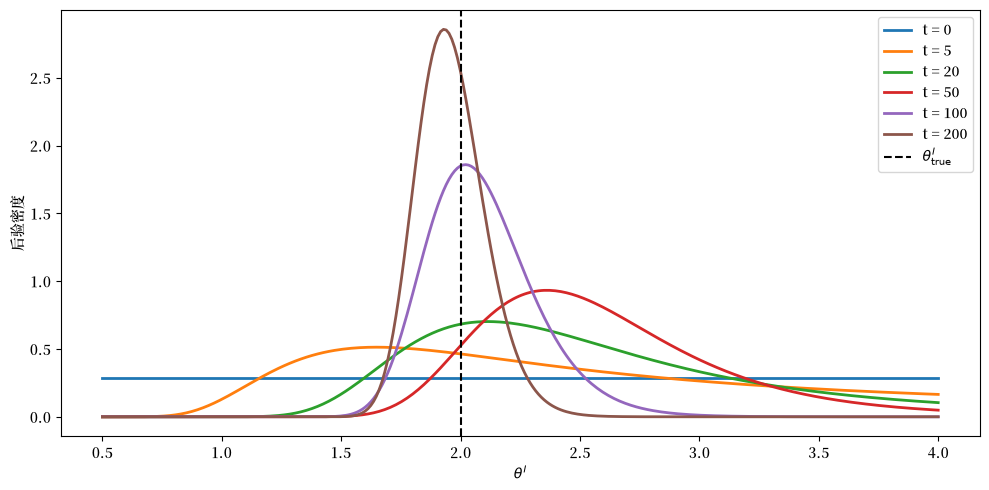

In [7]:
import matplotlib as mpl  # i18n
FONTPATH = "fonts/SourceHanSerifSC-SemiBold.otf"  # i18n
mpl.font_manager.fontManager.addfont(FONTPATH)  # i18n
mpl.rcParams['font.family'] = ['Source Han Serif SC']  # i18n
fig, ax = plt.subplots(figsize=(10, 5))
for t, ft in sorted(res['snapshots'].items()):
    ax.plot(res['θ_grid'], ft, lw=2, label=f't = {t}')
ax.axvline(params['θ_I_true'], color='black', ls='--', lw=1.5,
           label=r'$\theta^I_{\rm true}$')
ax.set_xlabel(r'$\theta^I$')
ax.set_ylabel('后验密度')
ax.legend()
plt.tight_layout()
plt.show()

随着价格和回报数据的积累，后验在 $\theta^I_{\rm true} = 2$ 周围收紧。

下一幅图追踪后验均值和方差。

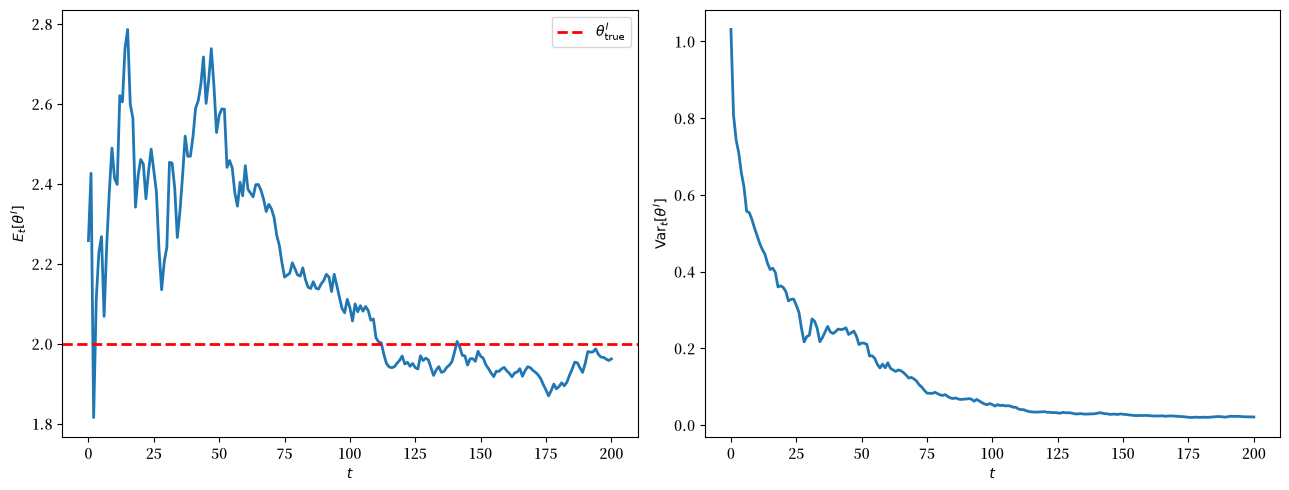

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(np.arange(params['T'] + 1), res['post_mean'], lw=2)
ax.axhline(params['θ_I_true'], color='red', ls='--', lw=2,
           label=r'$\theta^I_{\rm true}$')
ax.set_xlabel('$t$')
ax.set_ylabel(r'$E_t[\theta^I]$')
ax.legend()

ax = axes[1]
ax.plot(np.arange(params['T'] + 1), res['post_var'], lw=2)
ax.set_xlabel('$t$')
ax.set_ylabel(r'${\rm Var}_t[\theta^I]$')

plt.tight_layout()
plt.show()

后验均值收敛到真值，后验方差消失。

这是后验弱收敛到 $\theta^I_{\rm true}$ 处点质量的具体表现，我们将在下面用一般术语描述。

## 均衡交易与价格

均衡知情交易 $X^I_t$ 依赖于当前信号 $s_t$、$\theta^I_{\rm true}$ 以及结转的后验 $f_t$，这一切都通过市场出清系统 {eq}`eq:bk-mc`。

随着 $f_t$ 在 $\theta^I_{\rm true}$ 周围收紧，平均 $X^I_t$ 逼近 {eq}`eq:bk-full-info-trade` 中的完全传播配置。

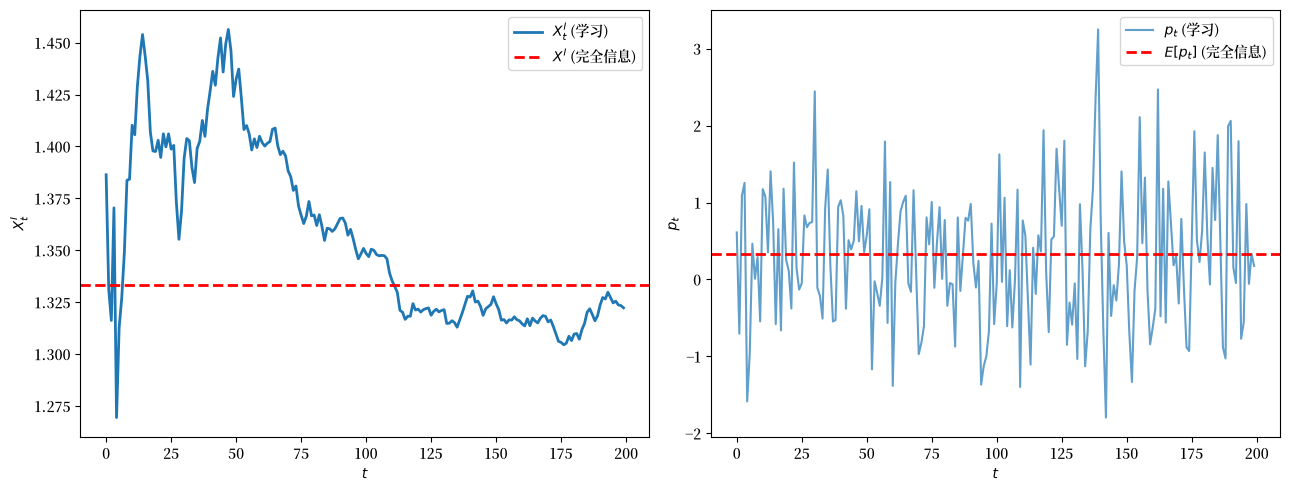

In [9]:
XI_full = 2 * params['θ_I_true'] / (params['θ_I_true'] + params['θ_U'])
p_mean_full = params['μ_s'] - params['σ2'] * XI_full / params['θ_I_true']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(res['XI_path'], lw=2, label='$X^I_t$ (学习)')
ax.axhline(XI_full, color='red', ls='--', lw=2,
           label='$X^I$ (完全信息)')
ax.set_xlabel('$t$')
ax.set_ylabel('$X^I_t$')
ax.legend()

ax = axes[1]
ax.plot(res['p_path'], lw=1.5, alpha=0.7, label='$p_t$ (学习)')
ax.axhline(p_mean_full, color='red', ls='--', lw=2,
           label='$E[p_t]$ (完全信息)')
ax.set_xlabel('$t$')
ax.set_ylabel('$p_t$')
ax.legend()

plt.tight_layout()
plt.show()

左图显示随着信念集中，$X^I_t$ 逼近完全信息配置。

右图显示价格路径，它会波动，因为 $p_t$ 继承了 $s_t$ 的变化。

该模拟说明了这一均衡的三个特征。

关于 $\theta^I$ 的后验密度在真值周围集中，后验方差消失，且均衡知情交易 $X^I_t$ 收敛到其完全信息基准。

接下来的章节将识别这些结果背后的定理以及它们所要求的假设。

我们首先陈述 {cite:t}`BrayKreps1987` 对抽象模型的两个收敛结果，然后专注于两主体示例，以确定推动关于真实 $\theta^I$ 集中的假设，最后解释这些假设何时会失效。

## 后验评估的收敛

设 $(\Omega, \mathcal F)$ 为承载均衡的可测空间。

在两主体示例中，$\Omega = \Theta \times \Phi^{\infty}$，其中 $\Theta = [a,b] \times \{\theta^U\}$ 收集结构参数，$\Phi$ 收集每期冲击 $(s_t, \epsilon_t)$，$\mathcal F$ 是乘积博雷尔 $\sigma$-域。

主体 $n$ 在日期 $0$ 以 $(\Omega, \mathcal F)$ 上的先验概率测度 $P^n$ 进入。

设 $G_t^n \subseteq \mathcal F$ 表示由主体 $n$ 至日期 $t$ 的私人信息生成的 $\sigma$-域，并设

$$
H_t^n(p)
=
G_t^n \vee \sigma(p_0, p_1, \dots, p_t)
$$

为加入了至日期 $t$ 的均衡价格观察的 $\sigma$-域。

尾 $\sigma$-域为

$$
H_\infty^n(p)
=
\bigvee_{t \ge 0} H_t^n(p).
$$

第一个结果，归功于 {cite:t}`BrayKreps1987`，表明任何事件的条件概率几乎必然收敛。

```{prf:proposition}
:label: prop-bk-event-convergence

固定一个主体 $n$ 和一个事件 $A \in \mathcal F$。

过程 $M_t = \mathbb{E}^n[\mathbf 1_A \mid H_t^n(p)]$ 是关于 $(H_t^n(p))_{t \ge 0}$ 的 $P^n$-有界鞅，且

$$
\lim_{t\to\infty}
\mathbb{E}^n[\mathbf 1_A \mid H_t^n(p)]
=
\mathbb{E}^n[\mathbf 1_A \mid H_\infty^n(p)],
\qquad P^n\text{-a.s.}
$$
```

证明是有界鞅收敛定理，其中 $M_t \in [0,1]$ 提供了极限识别所需的一致可积性。

{prf:ref}`prop-bk-event-convergence` 是后验评估的收敛，而不是向"正确"信念的收敛。

有两点值得说明。

"几乎必然"陈述是相对于主体 $n$ 自身的先验 $P^n$ 而言的，因此如果两个先验 $P^n$ 和 $P^{n'}$ 相互奇异，则结论未必在共同的 $P$-正测度事件上同时成立。

如果先验共享一个共同的零测集族，则同时收敛在一个共同零测集之外成立。

{cite:t}`BrayKreps1987` 的第二个结果将收敛从个别事件锐化到参数空间上的整个后验测度，给定关于 $\Theta$ 的拓扑假设。

```{prf:assumption}
:label: assum-bk-borel

参数空间 $\Theta$ 是一个完备可分度量（波兰）空间，且由其开集生成的 $\Theta$ 上的博雷尔 $\sigma$-域使得 $(\Theta, \mathcal B(\Theta))$ 成为一个博雷尔空间。
```

在两主体示例中，$\Theta = [a,b]$ 平凡地满足这个假设。

在 {prf:ref}`assum-bk-borel` 下，可以固定条件概率的正则版本：映射

$$
P_t^n: \Omega \to \mathcal P(\Theta),
\qquad
\omega \mapsto P_t^n(\omega),
$$

使得对每个可测 $A \subseteq \Theta$，$\omega \mapsto P_t^n(\omega)(A)$ 是 $\mathbb{E}^n[\mathbf 1_{A \times \Phi^\infty} \mid H_t^n(p)](\omega)$ 的一个版本，且 $P_t^n(\omega) \in \mathcal P(\Theta)$ 是 $P^n$-几乎必然的概率测度。

锐化后的收敛结果表明这些正则版本几乎必然弱收敛。

```{prf:proposition}
:label: prop-bk-measure-convergence

在 {prf:ref}`assum-bk-borel` 下，正则版本 $P_t^n$ 弱收敛到正则版本 $P_\infty^n$，$P^n$-a.s.

等价地，对于 $P^n$-几乎每个 $\omega$ 和每个有界连续 $f: \Theta \to \mathbb R$，

$$
\int_\Theta f \, dP_t^n(\omega)
\xrightarrow[t \to \infty]{}
\int_\Theta f \, dP_\infty^n(\omega).
$$
```

{cite:t}`BrayKreps1987` 中的证明将 {prf:ref}`prop-bk-event-convergence` 应用于 $\Theta$ 的一个由 $1/k$-球构成的可数不相交划分（因为 $\Theta$ 是波兰空间所以该划分存在），然后调用有界连续函数上弱收敛的 Portmanteau 刻画。

因此，理性贝叶斯学习总是产生一个极限后验测度。

但 {prf:ref}`prop-bk-measure-convergence` 本身并不确定该极限是什么，在极限正确评估真值之前，还需要额外的结构。

## 锐化收敛结果

我们现在回到两主体示例，并识别使得 $P_\infty^U$ 是在真实 $\theta^I$ 处点质量的假设。

记 $F_t$ 为主体 $U$ 在观察 $(r_{t-1}, p_{t-1}, x^U_{t-1})$ 和所有更早数据后，在日期 $t$ 关于 $\theta^I$ 的后验的累积分布函数。

{prf:ref}`prop-bk-measure-convergence` 产生一个随机累积分布函数 $F_\infty$，使得 $F_t$ 弱收敛到 $F_\infty$，$P^U$-a.s.

三个要素将其锐化为关于真值的集中，对应于 {cite:t}`BrayKreps1987` 中的三个步骤。

```{prf:assumption}
:label: assum-bk-continuity

均衡不知情需求 $x^U(p, F)$ 关于弱收敛在 $F$ 上连续，且在一个 $P^U$-满测度价格集上关于 $p$ 一致连续。
```

```{prf:assumption}
:label: assum-bk-identification

对于固定的 $\theta^U$ 和极限后验 $F_\infty$，映射

$$
\theta^I
\mapsto
\mathcal L\{p_\infty(s; F_\infty, \theta^I, \theta^U)\}
$$

是单射的，其中 $s$ 从其边缘分布中抽取。

一个充分条件是该边缘价格分布在 $\theta^I$ 上的严格随机单调性。
```

在本讲座的 CARA-正态设置中，在隐式需求和价格方程所维持的唯一性和正则性下，这些假设是合理的。

连续性要求 {eq}`eq:bk-foc` 中一阶条件的根对 $F$ 的连续依赖，而不仅仅是积分的逐点连续性。

识别还使用了完整的均衡映射：方程 $p_t = s_t - \sigma^2 X^I_t / \theta^I$ 是有信息量的，但 $X^I_t$ 本身依赖于 $\theta^I$、$F_t$ 和均衡不动点。

关于 $\{s_t\}$ 的独立同分布假设（已经是模型的一部分）提供了下面步骤 2 中使用的遍历性。

在这三个假设和独立同分布信号序列下，两主体示例中的极限后验集中于真值。

```{prf:proposition}
:label: prop-bk-sharpening

假设 $\theta^I_{\rm true} \in [a,b]$，且先验 $f_0$ 在 $\theta^I_{\rm true}$ 的每个邻域中放置正密度。

在 {prf:ref}`assum-bk-borel`、{prf:ref}`assum-bk-continuity` 和 {prf:ref}`assum-bk-identification` 下，并给定独立同分布信号序列 $\{s_t\}$，关于 $\theta^I$ 的极限后验满足

$$
F_\infty
=
\delta_{\theta^I_{\rm true}}
\qquad P^U\text{-a.s.}
$$
```

证明有三个步骤。

*步骤 1：价格泛函收敛。*

{prf:ref}`assum-bk-continuity` 和来自 {prf:ref}`prop-bk-measure-convergence` 的弱收敛 $F_t \Rightarrow F_\infty$ 意味着均衡需求 $x^U(p, F_t)$ 收敛到 $x^U(p, F_\infty)$。

与市场出清和价格方程 {eq}`eq:bk-price` 结合，得到在一个 $P^U$-满测度集上 $p_t - p_\infty(s_t; F_\infty, \theta^I, \theta^U) \to 0$。

*步骤 2：极限价格分布是可观察的。*

由于偏差 $p_t - p_\infty(s_t; F_\infty, \theta^I, \theta^U) \to 0$ 几乎必然成立且 $\{s_t\}$ 是独立同分布的，观察到的价格的经验分布与极限价格泛函的经验分布具有相同的极限。

后者等于 $s \sim N(\mu_s, \tau^2)$ 时 $p_\infty(s; F_\infty, \theta^I, \theta^U)$ 的分布，而该极限作为一个可观察序列的长期频率是 $H_\infty^U(p)$-可测的。

*步骤 3：识别。*

{prf:ref}`assum-bk-identification` 使得 $p_\infty$ 的边缘分布在给定 $(F_\infty, \theta^U)$ 下识别 $\theta^I$。

与步骤 2 结合，这意味着 $\theta^I$ 本身是 $H_\infty^U(p)$-可测的，因此对于任何子区间 $[c,d] \subseteq [a,b]$，极限后验满足 $P_\infty^U(\theta^I \in [c,d]) = \mathbf 1_{\{\theta^I_{\rm true} \in [c,d]\}}$。

组合步骤 1、2 和 3 得到 $F_\infty = \delta_{\theta^I_{\rm true}}$。

上面的数值模拟与这个结果一致。

关于 $\theta^I$ 的后验密度坍缩为在 $\theta^I_{\rm true}=2$ 处的尖峰，且均衡知情交易 $X^I_t$ 收敛到完全信息值 $2\theta^I_{\rm true}/(\theta^I_{\rm true} + \theta^U)$。

因此，连接 {prf:ref}`prop-bk-event-convergence`（鞅收敛）到 {prf:ref}`prop-bk-sharpening`（关于真值的集中）的路径依赖于三个模型特定的要素：连续性、遍历性和识别。

## 收敛的障碍

自然地要问，这些要素何时会失效，以及对学习有何后果。

### 障碍 1：连续性失效

如果 {prf:ref}`assum-bk-continuity` 失效，证明的步骤 1 就会失败。

当均衡价格泛函在 $F$ 上不连续时，信念的微小变化可能产生价格信息含量的巨大变化，且信念的弱收敛未必意味着价格的收敛。

{cite:t}`BrayKreps1987` 将此标记为其论证中最微妙的步骤。

$x^U(p, F)$ 在 $F$ 上的连续性在本讲座的正则 CARA-正态情形中是合理的，但它也要求一阶条件解的唯一性以及该解对 $F$ 的连续依赖。

在更丰富的市场结构中验证同一性质通常需要非平凡的正则性论证。

### 障碍 2：识别失效

如果 {prf:ref}`assum-bk-identification` 失效，即使步骤 1 和步骤 2 成功，步骤 3 也会失败。

考虑一个变体，有两个知情主体，风险容忍度 $\theta^{I1}, \theta^{I2}$ 都为不知情主体所未知。

在有三个主体、每个各拥有一单位风险资产的情况下，完全传播公式 {eq}`eq:bk-full-communication-price` 给出

$$
p_t
=
s_t
-
\frac{3\sigma^2}{\theta^{I1} + \theta^{I2} + \theta^U},
$$

它仅通过和 $\theta^{I1}+\theta^{I2}$ 依赖于 $(\theta^{I1}, \theta^{I2})$。

{prf:ref}`prop-bk-measure-convergence` 仍然适用，但 $F_\infty$ 支撑在水平集

$$
\{(\theta_1, \theta_2) \in [a,b]^2 : \theta_1 + \theta_2 = \theta^{I1}_{\rm true} + \theta^{I2}_{\rm true}\},
$$

上，而不是单点集 $\{(\theta^{I1}_{\rm true},\theta^{I2}_{\rm true})\}$。

收敛发生了，但收敛到一个观察等价参数值的流形，而不是真值。

### 障碍 3：错误设定

如果真实的定价关系位于主体先验支撑之外，就会出现另一个障碍。

{cite:t}`BlumeEasley1982` 给出了这个障碍的一个风格化版本，而 {doc}`likelihood_ratio_process_2` 在本讲座系列中发展了 Blume-Easley 异质信念模型。

每个主体在给定自己的信息和价格下，对其他主体的信息持有相互竞争的条件似然。

可能存在一个均衡，其中主体对一个错误模型赋予渐近概率一，该模型给观察到的事件正似然，而真实的稳定价格关系接收零后验概率，因为该关系不存在于先验模型类中。

在严格的理性学习中，先验已经覆盖了真值：它支撑在扩展状态空间中贝叶斯一致的模型上，并对真实参数放置正权重。

贝叶斯法则只能重新加权那个初始模型类，因此一个先验概率为零的定价关系无论积累多少数据都保持为零。

## 在理性预期均衡内部学习 vs. 关于理性预期均衡的学习

上述框架指出了 {cite:t}`BrayKreps1987` 中一个重要的概念区分。

### 区分

在理性预期均衡*内部*学习是本讲座的主题。

它是在一个正确设定的模型内部的贝叶斯推断：{prf:ref}`assum-bk-borel`、{prf:ref}`assum-bk-continuity` 和 {prf:ref}`assum-bk-identification` 全部成立，且先验对真值放置正权重。

主体 $U$ 对 $\theta^I$ 不确定，但对于每个候选值，他已经知道均衡价格和配置映射。

扩展状态空间表述 $\Omega = \Theta \times \Phi^\infty$ 在更大的空间上嵌入了一个理性预期均衡，且推断简化为在 $\Theta$ 上的条件概率。

*关于*理性预期均衡的学习是一个根本不同的练习。

主体并不从他的概率模型中嵌入的均衡映射开始。

相反，他必须从在自己的信念和行为与数据共同演化时生成的数据中推断价格-状态关系。

### 权衡

这两个概念处于一个精确权衡的对立两侧。

一个正确设定的贝叶斯学习者享有 {prf:ref}`prop-bk-event-convergence` 和 {prf:ref}`prop-bk-measure-convergence` 中的收敛保证，但仅仅因为均衡从日期零起就已被内置到先验中。

一个将价格-状态关系视为需要估计的对象的适应性学习者，可以希望从数据中发现它，但他使用的估计量无法从应用于正确设定模型的贝叶斯法则中导出。

贝叶斯理性学习可以在主体先验中已经包含的均衡映射之间进行更新，但它并不解释主体最初如何获得这些映射。

关于*学习*理性预期均衡的文献，始于 {cite:t}`Bray1982` 和 {cite:t}`BraySavin1986`，并由 {cite:t}`MarcetSargent1989jet` 扩展，采取了权衡的第二侧，用**普通最小二乘法**或相关的递归估计量取代贝叶斯法则。

配套讲座 {doc}`ls_learning` 在自参照模型中发展了这个最小二乘学习框架，并通过相关的常微分方程追踪由此产生的动态。

那些法则在计算上易于处理，并在重要示例中收敛，但它们不是完全设定的理性学习均衡先验所隐含的贝叶斯更新。

## 小结

本讲座实现了 {cite:t}`BrayKreps1987` 的理性学习均衡。

后验评估通过有界鞅收敛而收敛（{prf:ref}`prop-bk-event-convergence`），且后验测度在波兰-博雷尔假设下弱收敛（{prf:ref}`prop-bk-measure-convergence`）。

关于真值的集中另外需要连续性（{prf:ref}`assum-bk-continuity`）、遍历性和识别（{prf:ref}`assum-bk-identification`）；上面的每个障碍都是其中之一的失效。

模拟说明了两个结论：关于 $\theta^I$ 的后验朝 $\theta^I_{\rm true}$ 坍缩，且均衡知情交易逼近其完全信息值。

理性学习描述了*给定*均衡结构下贝叶斯推断的极限；在 {doc}`ls_learning` 中的适应性学习则描述了该结构最初如何能被学到。


## 练习

````{exercise}
:label: rle_ex1

*偏离中心的先验*

基线模拟使用 $\theta^I \in [0.5, 4]$ 上的均匀先验。

1. 用一个质量位于真值*之上*的先验重新运行模拟，例如

```python
prior = lambda θ: (θ - 0.5)**3 * (4 - θ)
```

它在 $\theta = 3.1$ 附近达到峰值。

2. 绘制后验均值随时间的变化，与均匀先验基线并列。

3. 后验最终是否集中于 $\theta^I_{\rm true}$，速度相比如何？
````

```{solution-start} rle_ex1
:class: dropdown
```

这是一个解答：

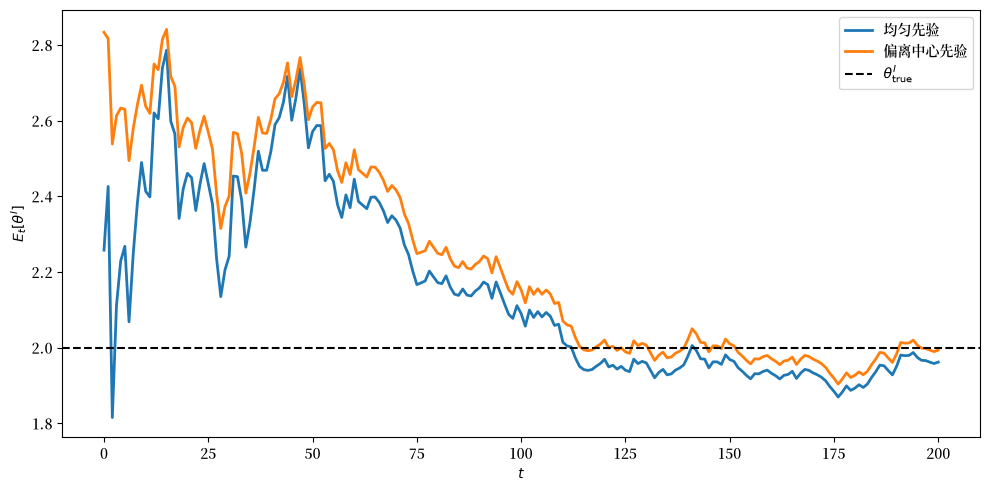

In [10]:
res_uniform = simulate(**params)

params_biased = dict(params)
params_biased['prior'] = lambda θ: (θ - 0.5)**3 * (4 - θ)
res_biased = simulate(**params_biased)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(res_uniform['post_mean'], lw=2, label='均匀先验')
ax.plot(res_biased['post_mean'], lw=2, label='偏离中心先验')
ax.axhline(params['θ_I_true'], color='black', ls='--',
           label=r'$\theta^I_{\rm true}$')
ax.set_xlabel('$t$')
ax.set_ylabel(r'$E_t[\theta^I]$')
ax.legend()
plt.tight_layout()
plt.show()

偏离中心的先验使后验均值起点远高于 $\theta^I_{\rm true} = 2$，但贝叶斯更新将其向下驱动到真值。

这是理性学习收敛结果的实际体现：任何对 $\theta^I_{\rm true}$ 放置正密度的先验最终都会在其周围集中。

```{solution-end}
```

```{exercise}
:label: rle_ex2

*不同 $\theta^I$ 下的学习速度*

一个时期关于 $\theta^I$ 的信息通过隐含信号

$$
s_t(\theta) = \frac{\sigma^2 X^I_t}{\theta} + p_t.
$$

传递。

灵敏度 $|\partial s_t/\partial \theta| = \sigma^2 X^I_t/\theta^2$ 通过 $X^I_t$ 和 $\theta^{-2}$ 依赖于 $\theta^I_{\rm true}$ 的水平。

1. 对 $\theta^I_{\rm true} \in \{0.8, 2.0, 3.5\}$ 运行模拟，其他所有参数保持在基线。

2. 对每种情形在对数刻度上绘制后验方差。

3. 哪个 $\theta^I_{\rm true}$ 值产生最快的集中，结果是否与上面的灵敏度公式相符？
```

```{solution-start} rle_ex2
:class: dropdown
```

这是一个解答：

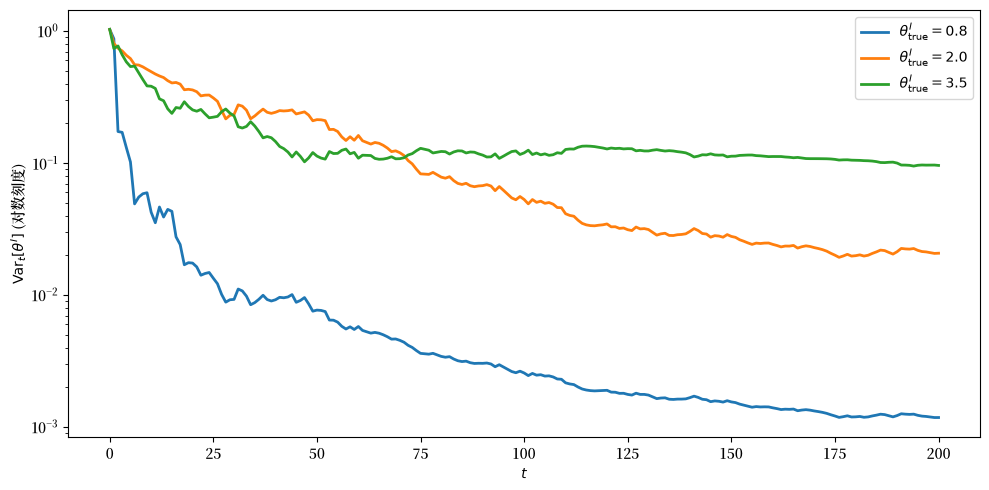

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
for θ_val in [0.8, 2.0, 3.5]:
    params_θ = dict(params)
    params_θ['θ_I_true'] = θ_val
    res_θ = simulate(**params_θ)
    ax.semilogy(res_θ['post_var'], lw=2,
                label=fr'$\theta^I_{{\rm true}} = {θ_val}$')
ax.set_xlabel('$t$')
ax.set_ylabel(r'${\rm Var}_t[\theta^I]$ (对数刻度)')
ax.legend()
plt.tight_layout()
plt.show()

最小的 $\theta^I_{\rm true}$ 产生后验方差最陡峭的下降。

原因是灵敏度 $\sigma^2 X^I_t/\theta^2$ 对固定的 $X^I_t$ 按 $\theta^{-2}$ 缩放，因此当 $\theta^I$ 较小时，相同的噪声水平传递关于 $\theta^I$ 的更多信息。

```{solution-end}
```

```{exercise}
:label: rle_ex3

*回报噪声的影响*

较大的 $\sigma^2$ 加宽了给定 $r_t$ 的 $s_t$ 的条件密度，人们可能猜测这会减慢学习。

但 $\sigma^2$ 也缩放 {eq}`eq:bk-price` 中的价格截距，因此跨候选 $\theta$ 的价格分散度随 $\sigma^2$ 增长。

1. 用 $\sigma^2 \in \{0.25, 1.0, 4.0\}$ 运行模拟，保持 $\tau^2 = 1$ 固定。

2. 对每个 $\sigma^2$ 在对数刻度上绘制后验方差。

3. 就从价格推断 $\theta^I$ 的信噪比而言，解释哪种效应占主导。
```

```{solution-start} rle_ex3
:class: dropdown
```

这是一个解答：

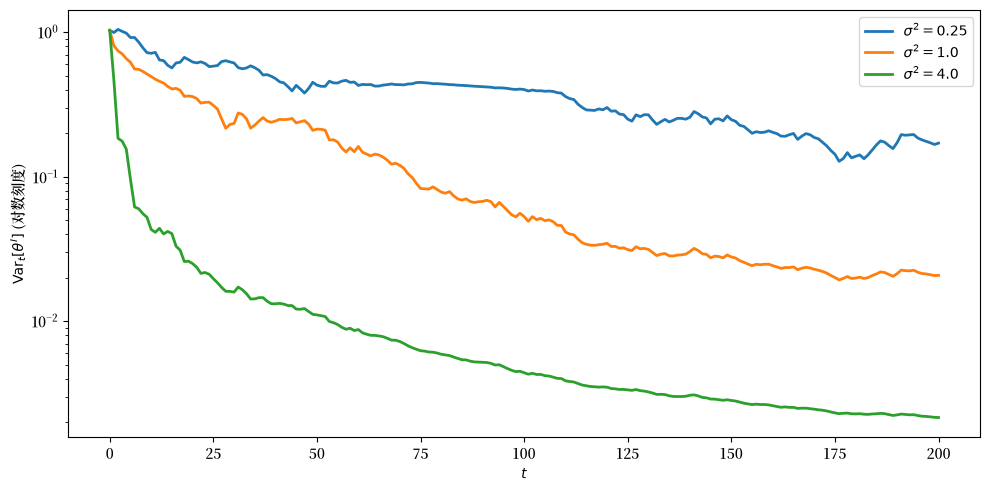

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
for σ2_val in [0.25, 1.0, 4.0]:
    params_σ = dict(params)
    params_σ['σ2'] = σ2_val
    res_σ = simulate(**params_σ)
    ax.semilogy(res_σ['post_var'], lw=2,
                label=fr'$\sigma^2 = {σ2_val}$')
ax.set_xlabel('$t$')
ax.set_ylabel(r'${\rm Var}_t[\theta^I]$ (对数刻度)')
ax.legend()
plt.tight_layout()
plt.show()

对于较大的 $\sigma^2$，后验方差下降得*更快*。

要理解原因，记 $\nu=\sigma^2$ 并固定实现的交易 $X^I_t$。

两个相近的 $\theta$ 值所隐含的信号大约相差

$$
\left|\frac{\partial s_t(\theta)}{\partial \theta}\right|
=
\frac{\nu |X^I_t|}{\theta^2}.
$$

似然使用 $g(s\mid r_t)$ 比较这些隐含信号，其条件方差为

$$
\operatorname{Var}(s_t\mid r_t)
=
\frac{\nu \tau^2}{\nu+\tau^2}.
$$

因此，区分相近 $\theta$ 值的局部信噪比正比于

$$
\frac{\nu |X^I_t|/\theta^2}
     {\sqrt{\nu\tau^2/(\nu+\tau^2)}}
=
\frac{|X^I_t|}{\theta^2}
\sqrt{\frac{\nu(\nu+\tau^2)}{\tau^2}},
$$

当 $\tau^2$ 固定时，这个比率随 $\nu$ 上升。

因此，在这个实验中价格揭示效应主导了额外的回报噪声。

```{solution-end}
```